In [1]:
import pathlib
import subprocess
import h5py
import numpy as np
import matplotlib.pyplot as plt
import re
import glob
import h5py
import matplotlib.animation as animation

import scipy.special as spl
import scipy.integrate
import mpmath as mpm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
import matplotlib.cm as cm

fontsize_title = 22
fontsize_axis = 18
fontsize_tick = 18
fontsize_legend = 16
fontsize_cbar = 18

plt.rcParams.update({
    "font.size": fontsize_tick,
    "axes.titlesize": fontsize_title,
    "axes.labelsize": fontsize_axis,
    "xtick.labelsize": fontsize_tick,
    "ytick.labelsize": fontsize_tick,
    "legend.fontsize": fontsize_legend,
    "figure.titlesize": fontsize_title,
})

In [2]:
import os

os.getcwd()

'/net/fs06/d0/dabdulah/GFD_PROJECT/crust_convection/mantle3D_xyperiodic_erosion_v1'

In [3]:
### 3-PANEL ANIMATION: p, h, C(z=z_index) ###

def make_p_h_C_animation(
    snapshot_dir="snapshots",
    file_prefix="snapshots_s",
    output_name="p_h_C_animation.gif",

    p_task="p",
    h_task="h",
    C_task="C",

    p_z_index=None,    # None means p is already 2D; otherwise slice p[:, :, z_index]
    h_z_index=None,    # None means h is already 2D; otherwise slice h[:, :, z_index]
    C_z_index=-2,      # C is sliced at this z index

    titles=("p", "h", "C"),

    cmaps=("RdBu_r", "RdBu_r", "RdBu_r"),
    vmins=(None, None, None),
    vmaxs=(None, None, None),

    fps=4,
    framecutoff=None,
    dpi=150,
    figsize=(15, 4.5),
    scale_from_last_half=True,
):
    """
    Makes a 3-panel animation:
        panel 1: p
        panel 2: h
        panel 3: C at C_z_index

    Assumes 2D task shape:
        (time, x, y)

    Assumes 3D task shape:
        (time, x, y, z)

    p_z_index and h_z_index:
        None if already 2D
        integer if task is 3D and you want an xy slice
    """

    def natural_sort_key(path):
        return [int(s) if s.isdigit() else s for s in re.split(r"(\d+)", path)]

    def get_coord(dset, dim_index):
        keys = list(dset.dims[dim_index].keys())
        if len(keys) == 0:
            raise ValueError(f"No coordinate scale found for dimension {dim_index}")
        return np.asarray(dset.dims[dim_index][keys[0]])

    def find_snapshot_files(snapshot_dir, file_prefix):
        files = []
        i = 1
        while True:
            fname = os.path.join(snapshot_dir, f"{file_prefix}{i}.h5")
            if os.path.exists(fname):
                files.append(fname)
                i += 1
            else:
                break

        if len(files) == 0:
            files = sorted(glob.glob(os.path.join(snapshot_dir, "*.h5")), key=natural_sort_key)

        if len(files) == 0:
            raise FileNotFoundError(f"No snapshot files found in {snapshot_dir}")

        return files

    def read_xy_slice(file, task, it, z_index=None):
        dset = file["tasks"][task]

        if len(dset.shape) == 3:
            # shape: time, x, y
            return np.asarray(dset[it, :, :])

        elif len(dset.shape) == 4:
            # shape: time, x, y, z
            if z_index is None:
                raise ValueError(f"{task} is 3D, so you must provide a z_index")
            return np.asarray(dset[it, :, :, z_index])

        else:
            raise ValueError(f"Unexpected shape for {task}: {dset.shape}")

    def get_xy_coords(dset):
        # works for both (time,x,y) and (time,x,y,z)
        x = get_coord(dset, 1)
        y = get_coord(dset, 2)
        return x, y

    # ----------------------------
    # Find files and collect frames
    # ----------------------------
    files = find_snapshot_files(snapshot_dir, file_prefix)
    print(f"Found {len(files)} files.")

    frames = []

    for fname in files:
        print(f"Scanning {fname}")
        with h5py.File(fname, "r") as f:
            dset = f["tasks"][p_task]
            t = np.asarray(dset.dims[0]["sim_time"])
            nt = dset.shape[0]

            for it in range(nt):
                frames.append((fname, it, t[it]))

    frames = sorted(frames, key=lambda x: x[2])
    print(f"Total frames: {len(frames)}")

    # ----------------------------
    # Coordinates
    # ----------------------------
    first_fname, first_it, first_time = frames[0]

    with h5py.File(first_fname, "r") as f:
        # Prefer p coords, fallback to h, fallback to C
        try:
            x, y = get_xy_coords(f["tasks"][p_task])
        except Exception:
            try:
                x, y = get_xy_coords(f["tasks"][h_task])
            except Exception:
                x, y = get_xy_coords(f["tasks"][C_task])

    X, Y = np.meshgrid(x, y, indexing="ij")

    print("x shape:", x.shape, "min/max:", x.min(), x.max())
    print("y shape:", y.shape, "min/max:", y.min(), y.max())
    print("C_z_index:", C_z_index)

    # ----------------------------
    # Color limits
    # ----------------------------
    tasks = (p_task, h_task, C_task)
    z_indices = (p_z_index, h_z_index, C_z_index)

    vmins = list(vmins)
    vmaxs = list(vmaxs)

    scan_frames = frames[len(frames)//2:] if scale_from_last_half else frames

    for i, (task, zi) in enumerate(zip(tasks, z_indices)):
        if vmins[i] is not None and vmaxs[i] is not None:
            continue

        vals = []
        print(f"Scanning color limits for {task}...")

        for fname, it, sim_time in scan_frames:
            with h5py.File(fname, "r") as f:
                A = read_xy_slice(f, task, it, zi)
                vals.append(np.nanmin(A))
                vals.append(np.nanmax(A))

        if vmins[i] is None:
            vmins[i] = np.nanmin(vals)
        if vmaxs[i] is None:
            vmaxs[i] = np.nanmax(vals)

        print(f"{task} vmin/vmax:", vmins[i], vmaxs[i])

    # ----------------------------
    # Figure setup
    # ----------------------------
    fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)
    ims = []

    with h5py.File(first_fname, "r") as f:
        for ax, task, title, cmap, vmin, vmax, zi in zip(
            axes, tasks, titles, cmaps, vmins, vmaxs, z_indices
        ):
            A0 = read_xy_slice(f, task, first_it, zi)
            
            if cmap is None:
                cmap = mcolors.LinearSegmentedColormap.from_list(
                    "brown_to_red",
                    [
                        (0.00, "black"),
                        (0.25, "saddlebrown"),
                        (1.00, "lightcoral"),
                    ]
                )

            im = ax.pcolormesh(
                X, Y, A0,
                shading="auto",
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
            )

            ax.set_title(title)
            ax.set_xlabel("x")
            ax.set_ylabel("y")

            cbar = fig.colorbar(im, ax=ax, shrink=0.85)
            # no colorbar title, per request

            ims.append(im)

    fig.suptitle(f"time = {first_time:.2f}")

    # ----------------------------
    # Animation update
    # ----------------------------
    def update(frame_number):
        fname, it, sim_time = frames[frame_number]

        with h5py.File(fname, "r") as f:
            for im, task, zi in zip(ims, tasks, z_indices):
                A = read_xy_slice(f, task, it, zi)
                im.set_array(A.ravel())

        fig.suptitle(f"time = {sim_time:.2f}")

        print(
            f"Frame {frame_number + 1}/{framenum}: "
            f"{fname}, index {it}, time {sim_time:.2f}"
        )

        return ims

    if framecutoff:
        framenum = framecutoff
    else:
        framenum = len(frames)

    ani = animation.FuncAnimation(
        fig,
        update,
        frames=framenum,
        interval=1000 / fps,
        blit=False,
    )

    ani.save(output_name, writer="pillow", fps=fps, dpi=dpi)
    print(f"Saved animation to {output_name}")



Found 9 files.
Scanning snapshots_noerosion/snapshots_noerosion_s1.h5
Scanning snapshots_noerosion/snapshots_noerosion_s2.h5
Scanning snapshots_noerosion/snapshots_noerosion_s3.h5
Scanning snapshots_noerosion/snapshots_noerosion_s4.h5
Scanning snapshots_noerosion/snapshots_noerosion_s5.h5
Scanning snapshots_noerosion/snapshots_noerosion_s6.h5
Scanning snapshots_noerosion/snapshots_noerosion_s7.h5
Scanning snapshots_noerosion/snapshots_noerosion_s8.h5
Scanning snapshots_noerosion/snapshots_noerosion_s9.h5
Total frames: 81
x shape: (128,) min/max: 0.0 3.96875
y shape: (128,) min/max: 0.0 3.96875
C_z_index: -4
Scanning color limits for p...
p vmin/vmax: -7405.700646457477 -6382.749595698219
Scanning color limits for w...
w vmin/vmax: -0.03881272700988947 0.03178178539079757
Scanning color limits for C...
C vmin/vmax: 0.07057661732573084 0.7211732888998733
Frame 1/81: snapshots_noerosion/snapshots_noerosion_s1.h5, index 0, time 0.00
Frame 1/81: snapshots_noerosion/snapshots_noerosion_s1.h5

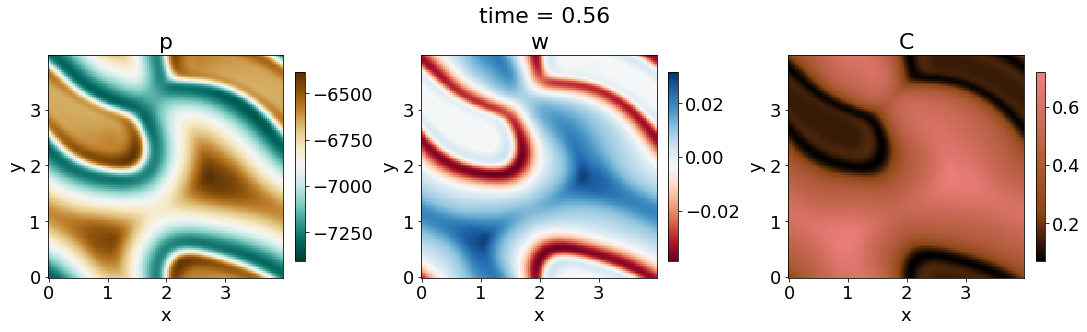

In [4]:
make_p_h_C_animation(
    snapshot_dir="snapshots_noerosion",
    file_prefix="snapshots_noerosion_s",
    output_name="p_h_C_noerosion.gif",

    p_task="p",
    h_task="w",
    C_task="C",

    p_z_index=-1,     # use None if p is already saved as 2D top surface
    h_z_index=-1,   # h should usually be 2D
    C_z_index=-4,

    titles=("p", "w", "C"),

    cmaps=("BrBG_r", "RdBu", None),
    vmins=(None, None, None),
    vmaxs=(None, None, None),

    fps=4,
    framecutoff=None,
    dpi=150,
    figsize=(15, 4.5),
)

Found 1 files.
Scanning snapshots_Kh/snapshots_Kh_s1.h5
Total frames: 2
x shape: (128,) min/max: 0.0 3.96875
y shape: (128,) min/max: 0.0 3.96875
C_z_index: -4
Scanning color limits for p...
p vmin/vmax: -8254.857995451657 -7805.853425210069
Scanning color limits for w...
w vmin/vmax: -0.030388823996924278 0.030437021687451948
Scanning color limits for C...
C vmin/vmax: 0.11203357767301483 0.4824248080706302
Frame 1/2: snapshots_Kh/snapshots_Kh_s1.h5, index 0, time 0.00
Frame 1/2: snapshots_Kh/snapshots_Kh_s1.h5, index 0, time 0.00
Frame 2/2: snapshots_Kh/snapshots_Kh_s1.h5, index 1, time 0.05
Saved animation to p_h_C_Kh.gif


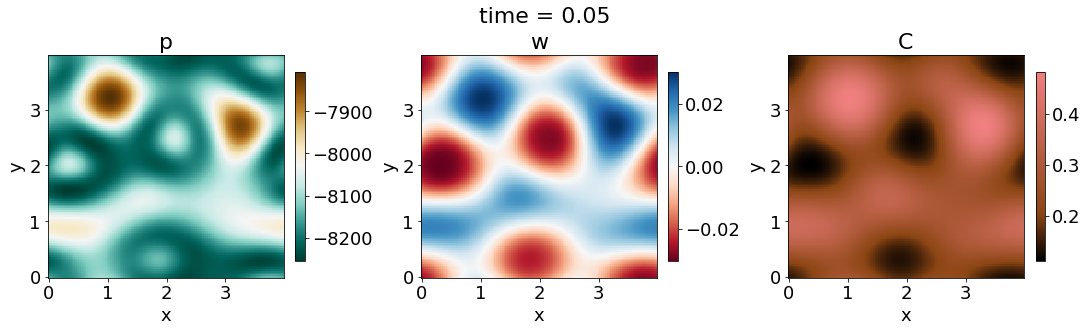

In [8]:
make_p_h_C_animation(
    snapshot_dir="snapshots_Kh",
    file_prefix="snapshots_Kh_s",
    output_name="p_h_C_Kh.gif",

    p_task="p",
    h_task="w",
    C_task="C",

    p_z_index=-1,     # use None if p is already saved as 2D top surface
    h_z_index=-1,   # h should usually be 2D
    C_z_index=-4,

    titles=("p", "w", "C"),

    cmaps=("BrBG_r", "RdBu", None),
    vmins=(None, None, None),
    vmaxs=(None, None, None),

    fps=4,
    framecutoff=None,
    dpi=150,
    figsize=(15, 4.5),
)

Found 1 files.
Scanning snapshots_Ks/snapshots_Ks_s1.h5
Total frames: 2
x shape: (128,) min/max: 0.0 3.96875
y shape: (128,) min/max: 0.0 3.96875
C_z_index: -4
Scanning color limits for p...
p vmin/vmax: -8254.737182678191 -7799.676480773825
Scanning color limits for w...
w vmin/vmax: -0.030306155040456965 0.03372773152028462
Scanning color limits for C...
C vmin/vmax: 0.111165494963344 0.48591974659335235
Frame 1/2: snapshots_Ks/snapshots_Ks_s1.h5, index 0, time 0.00
Frame 1/2: snapshots_Ks/snapshots_Ks_s1.h5, index 0, time 0.00
Frame 2/2: snapshots_Ks/snapshots_Ks_s1.h5, index 1, time 0.05
Saved animation to p_h_C_Ks.gif


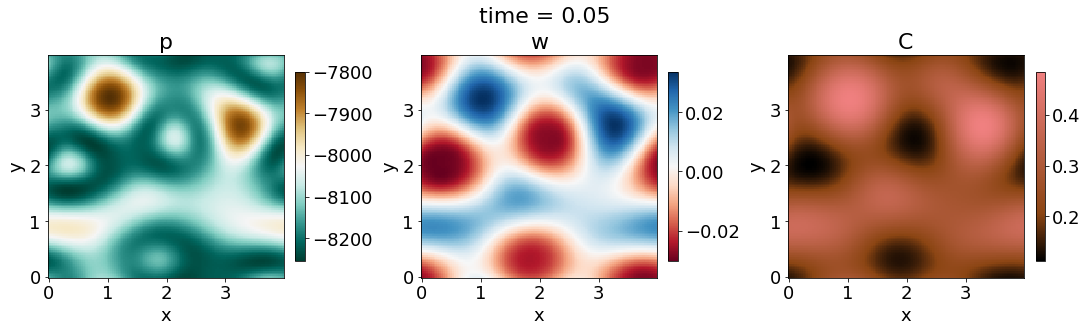

In [7]:
make_p_h_C_animation(
    snapshot_dir="snapshots_Ks",
    file_prefix="snapshots_Ks_s",
    output_name="p_h_C_Ks.gif",

    p_task="p",
    h_task="w",
    C_task="C",

    p_z_index=-1,     # use None if p is already saved as 2D top surface
    h_z_index=-1,   # h should usually be 2D
    C_z_index=-4,

    titles=("p", "w", "C"),

    cmaps=("BrBG_r", "RdBu", None),
    vmins=(None, None, None),
    vmaxs=(None, None, None),

    fps=4,
    framecutoff=None,
    dpi=150,
    figsize=(15, 4.5),
)